In [1]:
#import statements
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import nilearn.image
import nilearn.plotting
import copy
from torch.utils.data import random_split
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from pathlib import Path
import ants
import pydicom
import nibabel as nib
import os
from glob import glob
from tqdm import tqdm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchinfo import summary
import nilearn

In [3]:
def dicom_to_adc_map(dicom_dir, output_path=None):
    """
    Convert DICOM files from a directory to a raw DTI ADC map (numpy array or NIfTI).
    
    Parameters:
    -----------
    dicom_dir : str or Path
        Path to directory containing DICOM files
    output_path : str or Path, optional
        If provided, saves as NIfTI file at this path
        
    Returns:
    --------
    adc_map : numpy.ndarray
        3D array of ADC values
    affine : numpy.ndarray
        Affine transformation matrix
    """
    dicom_dir = Path(dicom_dir)
    dicom_files = list(dicom_dir.glob("*.dcm")) + list(dicom_dir.glob("*.DCM"))
    
    if not dicom_files:
        raise ValueError(f"No DICOM files found in {dicom_dir}")
    
    # Read all DICOM files
    dicom_datasets = []
    for dcm_file in dicom_files:
        try:
            ds = pydicom.dcmread(str(dcm_file))
            dicom_datasets.append(ds)
        except Exception as e:
            print(f"Warning: Could not read {dcm_file}: {e}")
            continue
    
    if not dicom_datasets:
        raise ValueError("No valid DICOM files could be read")
    
    # Sort by slice location (ImagePositionPatient[2]) or InstanceNumber
    def get_slice_location(ds):
        if hasattr(ds, 'SliceLocation') and ds.SliceLocation is not None:
            return float(ds.SliceLocation)
        elif hasattr(ds, 'ImagePositionPatient') and ds.ImagePositionPatient is not None:
            return float(ds.ImagePositionPatient[2])
        elif hasattr(ds, 'InstanceNumber') and ds.InstanceNumber is not None:
            return float(ds.InstanceNumber)
        else:
            return 0.0
    
    dicom_datasets.sort(key=get_slice_location)
    
    # Get pixel data and spacing
    pixel_data = []
    for ds in dicom_datasets:
        # Get pixel array (apply rescale slope/intercept if present)
        pixels = ds.pixel_array.astype(np.float32)
        
        # Apply rescale slope and intercept if available
        if hasattr(ds, 'RescaleSlope'):
            pixels = pixels * float(ds.RescaleSlope)
        if hasattr(ds, 'RescaleIntercept'):
            pixels = pixels + float(ds.RescaleIntercept)
        
        pixel_data.append(pixels)
    
    # Stack into 3D array
    adc_map = np.stack(pixel_data, axis=0)  # Shape: (slices, height, width)
    
    # Get voxel spacing and orientation
    first_ds = dicom_datasets[0]
    
    # Pixel spacing
    if hasattr(first_ds, 'PixelSpacing') and first_ds.PixelSpacing:
        pixel_spacing = [float(x) for x in first_ds.PixelSpacing]
    else:
        pixel_spacing = [1.0, 1.0]  # Default
    
    # Slice thickness/spacing
    if hasattr(first_ds, 'SpacingBetweenSlices') and first_ds.SpacingBetweenSlices:
        slice_spacing = float(first_ds.SpacingBetweenSlices)
    elif len(dicom_datasets) > 1:
        # Calculate from slice locations
        slice_locs = [get_slice_location(ds) for ds in dicom_datasets]
        slice_spacing = abs(slice_locs[1] - slice_locs[0]) if len(slice_locs) > 1 else 1.0
    else:
        slice_spacing = 1.0
    
    # Create affine matrix (simple version - may need adjustment based on DICOM orientation)
    affine = np.eye(4)
    affine[0, 0] = pixel_spacing[0]  # x spacing
    affine[1, 1] = pixel_spacing[1]  # y spacing
    affine[2, 2] = slice_spacing     # z spacing
    
    # Get image position if available
    if hasattr(first_ds, 'ImagePositionPatient') and first_ds.ImagePositionPatient:
        affine[:3, 3] = [float(x) for x in first_ds.ImagePositionPatient]
    
    # Save as NIfTI if output path provided
    if output_path:
        nii_img = nib.Nifti1Image(adc_map, affine)
        nib.save(nii_img, str(output_path))
        print(f"Saved ADC map to {output_path}")
        print(f"Shape: {adc_map.shape}, Spacing: {pixel_spacing + [slice_spacing]}")
    
    return adc_map, affine

In [4]:
def dicom_to_t1_mri(dicom_dir, output_path=None):
    """
    Convert T1 MRI DICOM files from a directory to a NIfTI file.
    
    Parameters:
    -----------
    dicom_dir : str or Path
        Path to directory containing DICOM files
    output_path : str or Path, optional
        If provided, saves as NIfTI file at this path
        
    Returns:
    --------
    t1_volume : numpy.ndarray
        3D array of T1 MRI values
    affine : numpy.ndarray
        Affine transformation matrix
    """
    dicom_dir = Path(dicom_dir)
    dicom_files = list(dicom_dir.glob("*.dcm")) + list(dicom_dir.glob("*.DCM"))
    
    if not dicom_files:
        raise ValueError(f"No DICOM files found in {dicom_dir}")
    
    # Read all DICOM files
    dicom_datasets = []
    for dcm_file in dicom_files:
        try:
            ds = pydicom.dcmread(str(dcm_file))
            dicom_datasets.append(ds)
        except Exception as e:
            print(f"Warning: Could not read {dcm_file}: {e}")
            continue
    
    if not dicom_datasets:
        raise ValueError("No valid DICOM files could be read")
    
    # Sort by slice location (ImagePositionPatient[2]) or InstanceNumber
    def get_slice_location(ds):
        if hasattr(ds, 'SliceLocation') and ds.SliceLocation is not None:
            return float(ds.SliceLocation)
        elif hasattr(ds, 'ImagePositionPatient') and ds.ImagePositionPatient is not None:
            return float(ds.ImagePositionPatient[2])
        elif hasattr(ds, 'InstanceNumber') and ds.InstanceNumber is not None:
            return float(ds.InstanceNumber)
        else:
            return 0.0
    
    dicom_datasets.sort(key=get_slice_location)
    
    # Get pixel data and spacing
    pixel_data = []
    for ds in dicom_datasets:
        # Get pixel array (apply rescale slope/intercept if present)
        pixels = ds.pixel_array.astype(np.float32)
        
        # Apply rescale slope and intercept if available
        if hasattr(ds, 'RescaleSlope'):
            pixels = pixels * float(ds.RescaleSlope)
        if hasattr(ds, 'RescaleIntercept'):
            pixels = pixels + float(ds.RescaleIntercept)
        
        pixel_data.append(pixels)
    
    # Handle single 3D DICOM file or stack multiple 2D slices
    if len(pixel_data) == 1 and len(pixel_data[0].shape) == 3:
        # Single DICOM file with 3D volume
        t1_volume = pixel_data[0]
    elif len(pixel_data) > 0:
        # Multiple 2D slices - stack them
        t1_volume = np.stack(pixel_data, axis=0)  # Shape: (slices, height, width)
    else:
        raise ValueError("No valid pixel data found")
    
    # Get voxel spacing and orientation
    first_ds = dicom_datasets[0]
    
    # Pixel spacing
    if hasattr(first_ds, 'PixelSpacing') and first_ds.PixelSpacing:
        pixel_spacing = [float(x) for x in first_ds.PixelSpacing]
    else:
        pixel_spacing = [1.0, 1.0]  # Default
    
    # Slice thickness/spacing
    if hasattr(first_ds, 'SpacingBetweenSlices') and first_ds.SpacingBetweenSlices:
        slice_spacing = float(first_ds.SpacingBetweenSlices)
    elif len(dicom_datasets) > 1:
        # Calculate from slice locations
        slice_locs = [get_slice_location(ds) for ds in dicom_datasets]
        slice_spacing = abs(slice_locs[1] - slice_locs[0]) if len(slice_locs) > 1 else 1.0
    else:
        slice_spacing = 1.0
    
    # Create affine matrix (simple version - may need adjustment based on DICOM orientation)
    affine = np.eye(4)
    affine[0, 0] = pixel_spacing[0]  # x spacing
    affine[1, 1] = pixel_spacing[1]  # y spacing
    affine[2, 2] = slice_spacing     # z spacing
    
    # Get image position if available
    if hasattr(first_ds, 'ImagePositionPatient') and first_ds.ImagePositionPatient:
        affine[:3, 3] = [float(x) for x in first_ds.ImagePositionPatient]
    
    # Save as NIfTI if output path provided
    if output_path:
        nii_img = nib.Nifti1Image(t1_volume, affine)
        nib.save(nii_img, str(output_path))
        print(f"Saved T1 MRI to {output_path}")
        print(f"Shape: {t1_volume.shape}, Spacing: {pixel_spacing + [slice_spacing]}")
    
    return t1_volume, affine

In [5]:
# Process all I* folders in t1_mri_dcm and save to t1_mri_raw
t1_base_dir = Path("model_data/adni/t1_mri_dcm")
t1_output_dir = Path("model_data/adni/t1_mri_raw")
t1_output_dir.mkdir(parents=True, exist_ok=True)

# Collect all I* folders that contain DICOM files
t1_i_folders = [f for f in t1_base_dir.rglob("I*") 
                if f.is_dir() and (any(f.glob("*.dcm")) or any(f.glob("*.DCM")))]

# Initialize counters
t1_processed = 0
t1_errors = 0

In [6]:
# Process each folder with progress bar
for i_folder in tqdm(t1_i_folders, desc="Processing T1 MRI DICOM folders"):
    try:
        # Extract image_id (the I* folder name, e.g., I1593283)
        image_id = i_folder.name
        
        # Extract subject_id from the relative path
        # The structure is: t1_mri_dcm/[subject_id]/.../I[image_id]
        relative_path = i_folder.relative_to(t1_base_dir)
        subject_id = relative_path.parts[0]  # First part is the subject_id
        
        # Create output filename: I[image_id]_[subject_id].nii
        output_filename = f"{image_id}_{subject_id}.nii"
        output_path = t1_output_dir / output_filename
        
        # Skip if already exists
        if output_path.exists():
            continue
        
        # Convert DICOM to T1 MRI NIfTI
        t1_volume, affine = dicom_to_t1_mri(i_folder, output_path)
        t1_processed += 1
        
    except Exception as e:
        print(f"\nError processing {i_folder}: {e}")
        t1_errors += 1
        continue

print(f"\nT1 MRI Processing complete!")
print(f"Successfully processed: {t1_processed}")
print(f"Errors: {t1_errors}")

Processing T1 MRI DICOM folders:   0%|          | 0/295 [00:00<?, ?it/s]

/Users/william.wakefield/PycharmProjects/ADRU/.venv/lib/python3.12/site-packages/nibabel/nifti1.py:1244: RuntimeWarning: invalid value encountered in divide
  R = RZS / zooms
/Users/william.wakefield/PycharmProjects/ADRU/.venv/lib/python3.12/site-packages/numpy/linalg/_linalg.py:2431: RuntimeWarning: invalid value encountered in det
  r = _umath_linalg.det(a, signature=signature)
Processing T1 MRI DICOM folders: 100%|██████████| 295/295 [00:00<00:00, 1072.93it/s]


Error processing model_data/adni/t1_mri_dcm/016_S_4952/Accelerated_Sagittal_MPRAGE/2017-02-14_07_22_09.0/I820315: Could not decompose affine:
[[   1.0546875     0.            0.          -98.2203373 ]
 [   0.            1.0546875     0.         -117.07097435]
 [   0.            0.            0.          147.88135624]
 [   0.            0.            0.            1.        ]]

T1 MRI Processing complete!
Successfully processed: 0
Errors: 1


In [7]:
# Example usage for your ADNI data structure:
# For a single subject's ADC map:
adc_map, affine = dicom_to_adc_map(
    "model_data/adni/dti_dcm/002_S_1280/Axial_DTI_ADC/2017-03-13_14_12_25.0/I829303",
    output_path="model_data/adni/dti_raw/I829303_002_S_1280_ADC.nii"
)

Saved ADC map to model_data/adni/dti_raw/I829303_002_S_1280_ADC.nii
Shape: (80, 116, 116), Spacing: [2.5172414779663, 2.5172414779663, 2.0]


In [8]:
# Process all I* folders in dti_dcm and save to dti_raw
base_dir = Path("model_data/adni/dti_dcm")
output_dir = Path("model_data/adni/dti_raw")
output_dir.mkdir(parents=True, exist_ok=True)

# Find all folders matching pattern I* (starting with I followed by digits)
processed = 0
errors = 0

In [8]:
# Collect all I* folders that contain DICOM files
i_folders = [f for f in base_dir.rglob("I*") 
             if f.is_dir() and (any(f.glob("*.dcm")) or any(f.glob("*.DCM")))]

In [12]:
# Process each folder with progress bar
for i_folder in tqdm(i_folders, desc="Processing DICOM folders"):
    try:
        # Extract image_id (the I* folder name, e.g., I829303)
        image_id = i_folder.name
        
        # Extract subject_id from the relative path
        # The structure is: dti_dcm/[subject_id]/.../I[image_id]
        relative_path = i_folder.relative_to(base_dir)
        subject_id = relative_path.parts[0]  # First part is the subject_id
        
        # Create output filename: I[image_id]_[subject_id].nii
        output_filename = f"{image_id}_{subject_id}.nii"
        output_path = output_dir / output_filename
        
        # Skip if already exists
        if output_path.exists():
            continue
        
        # Convert DICOM to ADC map
        adc_map, affine = dicom_to_adc_map(i_folder, output_path)
        processed += 1
        
    except Exception as e:
        print(f"\nError processing {i_folder}: {e}")
        errors += 1
        continue

print(f"\nProcessing complete!")
print(f"Successfully processed: {processed}")
print(f"Errors: {errors}")

Processing DICOM folders:   1%|          | 2/299 [00:00<00:25, 11.54it/s]

Saved ADC map to model_data/adni/dti_raw/I1593306_023_S_6400.nii
Shape: (1, 81, 116, 116), Spacing: [1.0, 1.0, 2.0]
Saved ADC map to model_data/adni/dti_raw/I1193759_016_S_6789.nii
Shape: (80, 116, 116), Spacing: [2.0, 2.0, 2.0]


Processing DICOM folders:   1%|▏         | 4/299 [00:00<00:22, 12.89it/s]

Saved ADC map to model_data/adni/dti_raw/I1116506_137_S_4631.nii
Shape: (80, 116, 116), Spacing: [2.0, 2.0, 2.0]
Saved ADC map to model_data/adni/dti_raw/I1282878_137_S_4631.nii
Shape: (80, 116, 116), Spacing: [2.0, 2.0, 2.0]
Saved ADC map to model_data/adni/dti_raw/I1417012_137_S_4631.nii
Shape: (80, 116, 116), Spacing: [2.0, 2.0, 2.0]


Processing DICOM folders:   3%|▎         | 8/299 [00:00<00:21, 13.58it/s]

...

Saved ADC map to model_data/adni/dti_raw/I980392_041_S_6226.nii
Shape: (80, 116, 116), Spacing: [2.0, 2.0, 2.0]
Saved ADC map to model_data/adni/dti_raw/I1348003_041_S_6226.nii
Shape: (80, 116, 116), Spacing: [2.0, 2.0, 2.0]


Processing DICOM folders:  99%|█████████▉| 297/299 [00:24<00:00, 13.34it/s]

Saved ADC map to model_data/adni/dti_raw/I893558_941_S_4292.nii
Shape: (80, 116, 116), Spacing: [2.0, 2.0, 2.0]
Saved ADC map to model_data/adni/dti_raw/I1142378_022_S_6013.nii
Shape: (40, 180, 180), Spacing: [1.2222222089767, 1.2222222089767, 4.0]
Saved ADC map to model_data/adni/dti_raw/I1220335_094_S_6736.nii
Shape: (85, 116, 116), Spacing: [2.0, 2.0, 2.0]
Saved ADC map to model_data/adni/dti_raw/I532648_068_S_4340.nii
Shape: (40, 74, 74), Spacing: [3.0, 3.0, 3.0]


Processing DICOM folders: 100%|██████████| 299/299 [00:24<00:00, 12.15it/s]

Saved ADC map to model_data/adni/dti_raw/I926813_137_S_4482.nii
Shape: (80, 116, 116), Spacing: [2.0, 2.0, 2.0]
Saved ADC map to model_data/adni/dti_raw/I1246457_137_S_4482.nii
Shape: (80, 116, 116), Spacing: [2.0, 2.0, 2.0]

Processing complete!
Successfully processed: 299
Errors: 0


In [15]:
# Create a numpy array of file paths for files with shape (80, 116, 116)
dti_raw_dir = Path("model_data/adni/dti_raw")

# Get all .nii files (including .nii.gz)
nii_files = list(dti_raw_dir.glob("*.nii")) + list(dti_raw_dir.glob("*.nii.gz"))

# Filter files by shape (80, 116, 116)
valid_file_paths = []

for nii_file in tqdm(nii_files, desc="Checking file shapes"):
    try:
        # Load the NIfTI file
        nii_img = nib.load(str(nii_file))
        data = nii_img.get_fdata()
        
        # Check if shape is (80, 116, 116)
        if data.shape == (80, 116, 116):
            valid_file_paths.append(str(nii_file))
    except Exception as e:
        print(f"\nError loading {nii_file}: {e}")
        continue

# Convert to numpy array
valid_file_paths_array = np.array(valid_file_paths, dtype=object)

print(f"\nFound {len(valid_file_paths_array)} files with shape (80, 116, 116)")
print(f"Total files checked: {len(nii_files)}")

Checking file shapes: 100%|██████████| 299/299 [00:02<00:00, 130.89it/s]


Found 235 files with shape (80, 116, 116)
Total files checked: 299


In [14]:
# Create a numpy array of file paths for T1 MRI files with shape (176, 256, 240)
t1_mri_raw_dir = Path("model_data/adni/t1_mri_raw")

# Get all .nii files (including .nii.gz)
t1_nii_files = list(t1_mri_raw_dir.glob("*.nii")) + list(t1_mri_raw_dir.glob("*.nii.gz"))

# Filter files by shape (176, 256, 240)
t1_valid_file_paths = []

for nii_file in tqdm(t1_nii_files, desc="Checking T1 MRI file shapes"):
    try:
        # Load the NIfTI file
        nii_img = nib.load(str(nii_file))
        data = nii_img.get_fdata()
        
        # Check if shape is (176, 256, 240)
        if data.shape == (176, 256, 240):
            t1_valid_file_paths.append(str(nii_file))
    except Exception as e:
        print(f"\nError loading {nii_file}: {e}")
        continue

# Convert to numpy array
t1_valid_file_paths_array = np.array(t1_valid_file_paths, dtype=object)

print(f"\nFound {len(t1_valid_file_paths_array)} T1 MRI files with shape (176, 256, 240)")
print(f"Total T1 MRI files checked: {len(t1_nii_files)}")

Checking T1 MRI file shapes: 100%|██████████| 294/294 [00:18<00:00, 15.84it/s]


Found 236 T1 MRI files with shape (176, 256, 240)
Total T1 MRI files checked: 294


In [16]:
# Compare subjects in T1 MRI and DTI arrays to find the difference
import re

# Extract subject IDs from file paths
def extract_subject_id(path):
    """Extract subject ID from path like '.../I[image_id]_[subject_id].nii'"""
    filename = Path(path).name
    # Pattern: I[image_id]_[subject_id].nii
    match = re.search(r'I\d+_(.+?)\.nii', filename)
    if match:
        return match.group(1)
    return None

In [17]:
# Create filtered arrays with only files from common subjects
import re

# Extract subject ID from file path
def extract_subject_id(path):
    """Extract subject ID from path like '.../I[image_id]_[subject_id].nii'"""
    filename = Path(path).name
    match = re.search(r'I\d+_(.+?)\.nii', filename)
    if match:
        return match.group(1)
    return None

# Get common subjects (from previous cell output: 129 common subjects)
# We'll recalculate to be sure
t1_subjects = set()
for path in t1_valid_file_paths_array:
    subject_id = extract_subject_id(path)
    if subject_id:
        t1_subjects.add(subject_id)

dti_subjects = set()
for path in valid_file_paths_array:
    subject_id = extract_subject_id(path)
    if subject_id:
        dti_subjects.add(subject_id)

common_subjects = t1_subjects & dti_subjects

print(f"Common subjects: {len(common_subjects)}")

# Filter T1 MRI files to only include common subjects
t1_common_files = []
for path in t1_valid_file_paths_array:
    subject_id = extract_subject_id(path)
    if subject_id and subject_id in common_subjects:
        t1_common_files.append(path)

# Filter DTI files to only include common subjects
dti_common_files = []
for path in valid_file_paths_array:
    subject_id = extract_subject_id(path)
    if subject_id and subject_id in common_subjects:
        dti_common_files.append(path)

# Create numpy arrays
t1_common_array = np.array(t1_common_files, dtype=object)
dti_common_array = np.array(dti_common_files, dtype=object)

print(f"\nT1 MRI files with common subjects: {len(t1_common_array)}")
print(f"DTI files with common subjects: {len(dti_common_array)}")

Common subjects: 129

T1 MRI files with common subjects: 202
DTI files with common subjects: 213


In [24]:
# Extract subject IDs from T1 MRI files
t1_subjects = set()
for path in t1_valid_file_paths_array:
    subject_id = extract_subject_id(path)
    if subject_id:
        t1_subjects.add(subject_id)

# Extract subject IDs from DTI files
dti_subjects = set()
for path in valid_file_paths_array:
    subject_id = extract_subject_id(path)
    if subject_id:
        dti_subjects.add(subject_id)

# Find differences
t1_only = t1_subjects - dti_subjects
dti_only = dti_subjects - t1_subjects
common_subjects = t1_subjects & dti_subjects

print(f"T1 MRI files: {len(t1_valid_file_paths_array)}")
print(f"DTI files: {len(valid_file_paths_array)}")
print()
print(f"Unique subjects in T1 MRI: {len(t1_subjects)}")
print(f"Unique subjects in DTI: {len(dti_subjects)}")
print(f"Common subjects: {len(common_subjects)}")

T1 MRI files: 236
DTI files: 235

Unique subjects in T1 MRI: 154
Unique subjects in DTI: 146
Common subjects: 129


In [25]:
if t1_only:
    print(f"Subjects in T1 MRI but NOT in DTI ({len(t1_only)}):")
    for subject in sorted(t1_only):
        # Find the T1 file for this subject
        t1_files = [p for p in t1_valid_file_paths_array if subject in Path(p).name]
        print(f"  {subject}: {t1_files[0] if t1_files else 'No file found'}")

if dti_only:
    print(f"\nSubjects in DTI but NOT in T1 MRI ({len(dti_only)}):")
    for subject in sorted(dti_only):
        # Find the DTI file for this subject
        dti_files = [p for p in valid_file_paths_array if subject in Path(p).name]
        print(f"  {subject}: {dti_files[0] if dti_files else 'No file found'}")

if not t1_only and not dti_only:
    print("All subjects match! The difference must be in multiple files per subject.")
    
    # Check for subjects with multiple files
    from collections import Counter
    
    t1_subject_counts = Counter([extract_subject_id(p) for p in t1_valid_file_paths_array if extract_subject_id(p)])
    dti_subject_counts = Counter([extract_subject_id(p) for p in valid_file_paths_array if extract_subject_id(p)])
    
    # Find subjects with different file counts
    print("\nChecking for subjects with different file counts:")
    all_subjects = t1_subject_counts.keys() | dti_subject_counts.keys()
    differences = []
    
    for subject in sorted(all_subjects):
        t1_count = t1_subject_counts.get(subject, 0)
        dti_count = dti_subject_counts.get(subject, 0)
        if t1_count != dti_count:
            differences.append((subject, t1_count, dti_count))
            print(f"  {subject}: T1={t1_count} files, DTI={dti_count} files")
            
            # Show the actual files
            t1_files = [p for p in t1_valid_file_paths_array if subject in Path(p).name]
            dti_files = [p for p in valid_file_paths_array if subject in Path(p).name]
            print(f"    T1 files: {[Path(p).name for p in t1_files]}")
            print(f"    DTI files: {[Path(p).name for p in dti_files]}")
    
    if not differences:
        print("  No differences found in subject file counts.")

Subjects in T1 MRI but NOT in DTI (25):
  003_S_4288: model_data/adni/t1_mri_raw/I1498579_003_S_4288.nii
  016_S_6708: model_data/adni/t1_mri_raw/I1151022_016_S_6708.nii
  022_S_6013: model_data/adni/t1_mri_raw/I1142379_022_S_6013.nii
  036_S_2380: model_data/adni/t1_mri_raw/I1023430_036_S_2380.nii
  036_S_4491: model_data/adni/t1_mri_raw/I984343_036_S_4491.nii
  036_S_6179: model_data/adni/t1_mri_raw/I957103_036_S_6179.nii
  036_S_6189: model_data/adni/t1_mri_raw/I958275_036_S_6189.nii
  036_S_6231: model_data/adni/t1_mri_raw/I973656_036_S_6231.nii
  036_S_6316: model_data/adni/t1_mri_raw/I991861_036_S_6316.nii
  036_S_6466: model_data/adni/t1_mri_raw/I1059028_036_S_6466.nii
  073_S_4777: model_data/adni/t1_mri_raw/I351121_073_S_4777.nii
  094_S_6736: model_data/adni/t1_mri_raw/I1220298_094_S_6736.nii
  114_S_2392: model_data/adni/t1_mri_raw/I1399029_114_S_2392.nii
  114_S_6057: model_data/adni/t1_mri_raw/I1581805_114_S_6057.nii
  114_S_6063: model_data/adni/t1_mri_raw/I1574100_114_S_

In [20]:
# Create dataframes for DTI and T1 MRI with file info including dates
import re
from datetime import datetime

def extract_info_from_filename(filename):
    """Extract image_id and subject_id from filename like 'I[image_id]_[subject_id].nii'"""
    match = re.match(r'I(\d+)_(.+?)\.nii', filename)
    if match:
        return match.group(1), match.group(2)
    return None, None

def find_date_from_dicom_folder(image_id, subject_id, base_dir):
    """Find the date from the original DICOM folder structure"""
    # Search for the I[image_id] folder for this subject
    subject_dir = base_dir / subject_id
    if not subject_dir.exists():
        return None
    
    # Search recursively for the I[image_id] folder
    for i_folder in subject_dir.rglob(f"I{image_id}"):
        if i_folder.is_dir():
            # Get the parent directory which should contain the date
            date_folder = i_folder.parent
            date_str = date_folder.name
            # Date format: 2017-03-13_14_12_25.0 or similar
            try:
                # Extract just the date part (before the time)
                date_part = date_str.split('_')[0]
                # Try to parse it
                datetime.strptime(date_part, '%Y-%m-%d')
                return date_str
            except:
                # If parsing fails, return the folder name anyway
                return date_str
    return None

In [21]:
# Process DTI files
dti_base_dir = Path("model_data/adni/dti_dcm")
dti_raw_dir = Path("model_data/adni/dti_raw")
dti_files = list(dti_raw_dir.glob("*.nii")) + list(dti_raw_dir.glob("*.nii.gz"))

dti_data = []
for nii_file in tqdm(dti_files, desc="Processing DTI files"):
    filename = nii_file.name
    image_id, subject_id = extract_info_from_filename(filename)
    
    if image_id and subject_id:
        # Find date from original DICOM folder
        date_taken = find_date_from_dicom_folder(image_id, subject_id, dti_base_dir)
        
        dti_data.append({
            'file_name': filename,
            'file_path': str(nii_file),
            'image_id': image_id,
            'subject_id': subject_id,
            'date_taken': date_taken
        })

dti_df = pd.DataFrame(dti_data)
print(f"DTI DataFrame: {len(dti_df)} files")
print(f"\nDTI DataFrame columns: {dti_df.columns.tolist()}")
print(f"\nFirst few rows:")
dti_df.head()

Processing DTI files: 100%|██████████| 299/299 [00:00<00:00, 2741.63it/s]

DTI DataFrame: 299 files

DTI DataFrame columns: ['file_name', 'file_path', 'image_id', 'subject_id', 'date_taken']

First few rows:


,file_name,file_path,image_id,subject_id,date_taken
0,I1223070_012_S_4188.nii,model_data/adni/dti_raw/I1223070_012_S_4188.nii,1223070,012_S_4188,2019-09-04_09_54_08.0
1,I893053_941_S_6068.nii,model_data/adni/dti_raw/I893053_941_S_6068.nii,893053,941_S_6068,2017-08-21_18_31_11.0
2,I980392_041_S_6226.nii,model_data/adni/dti_raw/I980392_041_S_6226.nii,980392,041_S_6226,2018-03-29_13_21_31.0
3,I1043642_137_S_6557.nii,model_data/adni/dti_raw/I1043642_137_S_6557.nii,1043642,137_S_6557,2018-08-28_17_13_57.0
4,I879765_041_S_4143.nii,model_data/adni/dti_raw/I879765_041_S_4143.nii,879765,041_S_4143,2017-07-27_13_27_20.0


In [22]:
# Process T1 MRI files
t1_base_dir = Path("model_data/adni/t1_mri_dcm")
t1_raw_dir = Path("model_data/adni/t1_mri_raw")
t1_files = list(t1_raw_dir.glob("*.nii")) + list(t1_raw_dir.glob("*.nii.gz"))

t1_data = []
for nii_file in tqdm(t1_files, desc="Processing T1 MRI files"):
    filename = nii_file.name
    image_id, subject_id = extract_info_from_filename(filename)
    
    if image_id and subject_id:
        # Find date from original DICOM folder
        date_taken = find_date_from_dicom_folder(image_id, subject_id, t1_base_dir)
        
        t1_data.append({
            'file_name': filename,
            'file_path': str(nii_file),
            'image_id': image_id,
            'subject_id': subject_id,
            'date_taken': date_taken
        })

t1_df = pd.DataFrame(t1_data)
print(f"\n\nT1 MRI DataFrame: {len(t1_df)} files")
print(f"\nT1 MRI DataFrame columns: {t1_df.columns.tolist()}")
print(f"\nFirst few rows:")
t1_df.head()

Processing T1 MRI files: 100%|██████████| 294/294 [00:00<00:00, 2700.54it/s]



T1 MRI DataFrame: 294 files

T1 MRI DataFrame columns: ['file_name', 'file_path', 'image_id', 'subject_id', 'date_taken']

First few rows:


,file_name,file_path,image_id,subject_id,date_taken
0,I1413030_016_S_5057.nii,model_data/adni/t1_mri_raw/I1413030_016_S_5057...,1413030,016_S_5057,2021-02-19_13_16_36.0
1,I1493847_016_S_7002.nii,model_data/adni/t1_mri_raw/I1493847_016_S_7002...,1493847,016_S_7002,2021-09-14_15_36_50.0
2,I904007_024_S_5290.nii,model_data/adni/t1_mri_raw/I904007_024_S_5290.nii,904007,024_S_5290,2017-09-12_08_00_50.0
3,I916492_036_S_6088.nii,model_data/adni/t1_mri_raw/I916492_036_S_6088.nii,916492,036_S_6088,2017-10-12_10_18_44.0
4,I1634890_016_S_7014.nii,model_data/adni/t1_mri_raw/I1634890_016_S_7014...,1634890,016_S_7014,2021-11-30_12_04_08.0


In [25]:
# Create paired dataset for common subjects
# Match DTI and T1 MRI images by date similarity, maximizing pairs

from datetime import datetime
from collections import defaultdict

def parse_date(date_str):
    """Parse date string like '2017-03-13_14_12_25.0' to datetime"""
    if pd.isna(date_str) or date_str is None:
        return None
    try:
        # Extract date part (before first underscore after date)
        date_part = str(date_str).split('_')[0]
        return datetime.strptime(date_part, '%Y-%m-%d')
    except:
        return None

def date_difference(date1, date2):
    """Calculate absolute difference in days between two dates"""
    if date1 is None or date2 is None:
        return float('inf')  # Large penalty for missing dates
    return abs((date1 - date2).days)

def match_images_by_date(dti_images, t1_images):
    """
    Match DTI and T1 images by date similarity using greedy algorithm.
    Returns list of pairs (dti_idx, t1_idx) maximizing matches.
    """
    if len(dti_images) == 0 or len(t1_images) == 0:
        return []
    
    # Parse dates for all images
    dti_dates = [parse_date(d['date_taken']) for d in dti_images]
    t1_dates = [parse_date(t['date_taken']) for t in t1_images]
    
    # Create list of all possible pairs with their date differences
    pairs = []
    for i, dti_img in enumerate(dti_images):
        for j, t1_img in enumerate(t1_images):
            diff = date_difference(dti_dates[i], t1_dates[j])
            pairs.append((diff, i, j))
    
    # Sort by date difference (smallest first)
    pairs.sort(key=lambda x: x[0])
    
    # Greedy matching: take pairs with smallest date differences
    # ensuring each image is used only once
    matched_dti = set()
    matched_t1 = set()
    matches = []
    
    for diff, dti_idx, t1_idx in pairs:
        if dti_idx not in matched_dti and t1_idx not in matched_t1:
            matches.append((dti_idx, t1_idx))
            matched_dti.add(dti_idx)
            matched_t1.add(t1_idx)
    
    return matches

In [26]:
# Filter dataframes to only common subjects
common_subjects_set = set(common_subjects)  # From previous cell

dti_common = dti_df[dti_df['subject_id'].isin(common_subjects_set)].copy()
t1_common = t1_df[t1_df['subject_id'].isin(common_subjects_set)].copy()

print(f"DTI files for common subjects: {len(dti_common)}")
print(f"T1 MRI files for common subjects: {len(t1_common)}")

DTI files for common subjects: 217
T1 MRI files for common subjects: 212


In [40]:
# Diagnostic: Verify pairing logic and check for duplicate usage
print("=== DIAGNOSTIC ANALYSIS ===\n")

# Verify counts
print("1. File Counts:")
print(f"   DTI files for common subjects: {len(dti_common)}")
print(f"   T1 MRI files for common subjects: {len(t1_common)}")
print(f"   Total pairs created: {len(paired_df)}")
print(f"   Maximum possible pairs (min of both): {min(len(dti_common), len(t1_common))}")
print()

# Check if any DTI images are used multiple times
dti_paths_in_pairs = paired_df['dti_file_path'].tolist()
dti_duplicates = [path for path in dti_paths_in_pairs if dti_paths_in_pairs.count(path) > 1]

print("2. Duplicate DTI Usage:")
if dti_duplicates:
    print(f"   WARNING: {len(set(dti_duplicates))} unique DTI files used multiple times!")
    for dup_path in set(dti_duplicates):
        count = dti_paths_in_pairs.count(dup_path)
        print(f"   {Path(dup_path).name}: used {count} times")
else:
    print("   ✓ No DTI files used multiple times")
print()

# Check if any T1 images are used multiple times
t1_paths_in_pairs = paired_df['t1_file_path'].tolist()
t1_duplicates = [path for path in t1_paths_in_pairs if t1_paths_in_pairs.count(path) > 1]

print("3. Duplicate T1 Usage:")
if t1_duplicates:
    print(f"   WARNING: {len(set(t1_duplicates))} unique T1 files used multiple times!")
    for dup_path in set(t1_duplicates):
        count = t1_paths_in_pairs.count(dup_path)
        print(f"   {Path(dup_path).name}: used {count} times")
else:
    print("   ✓ No T1 files used multiple times")
print()

# Check unique files used
unique_dti_used = len(set(dti_paths_in_pairs))
unique_t1_used = len(set(t1_paths_in_pairs))

print("4. Unique Files Used:")
print(f"   Unique DTI files in pairs: {unique_dti_used} (out of {len(dti_common)} total)")
print(f"   Unique T1 files in pairs: {unique_t1_used} (out of {len(t1_common)} total)")
print()

# Check subjects with multiple pairs
print("5. Subjects with Multiple Pairs:")
subject_pair_counts = paired_df['subject_id'].value_counts()
multi_pair_subjects = subject_pair_counts[subject_pair_counts > 1]
print(f"   Subjects with >1 pair: {len(multi_pair_subjects)}")
if len(multi_pair_subjects) > 0:
    print(f"   Max pairs per subject: {subject_pair_counts.max()}")
    print(f"   Example subjects with multiple pairs:")
    for subject, count in multi_pair_subjects.head(5).items():
        print(f"     {subject}: {count} pairs")
        # Show the pairs for this subject
        subject_pairs = paired_df[paired_df['subject_id'] == subject]
        for idx, row in subject_pairs.iterrows():
            print(f"       Pair: DTI={Path(row['dti_file_path']).name} (date: {row['dti_date_taken']}) "
                  f"<-> T1={Path(row['t1_file_path']).name} (date: {row['t1_date_taken']})")
print()

# Verify the matching logic by checking a specific subject
print("6. Detailed Check for One Subject:")
example_subject = subject_pair_counts.index[0] if len(subject_pair_counts) > 0 else None
if example_subject:
    print(f"   Subject: {example_subject}")
    subject_dti = [d for d in dti_by_subject[example_subject]]
    subject_t1 = [t for t in t1_by_subject[example_subject]]
    print(f"   DTI images for this subject: {len(subject_dti)}")
    print(f"   T1 images for this subject: {len(subject_t1)}")
    print(f"   Pairs created for this subject: {subject_pair_counts[example_subject]}")
    
    # Show all DTI and T1 images
    print(f"   DTI images:")
    for d in subject_dti:
        print(f"     {d['file_name']} (date: {d['date_taken']})")
    print(f"   T1 images:")
    for t in subject_t1:
        print(f"     {t['file_name']} (date: {t['date_taken']})")
    
    # Show which ones were paired
    subject_pairs = paired_df[paired_df['subject_id'] == example_subject]
    print(f"   Paired:")
    for idx, row in subject_pairs.iterrows():
        print(f"     {Path(row['dti_file_path']).name} <-> {Path(row['t1_file_path']).name}")

print("\n=== END DIAGNOSTIC ===")

=== DIAGNOSTIC ANALYSIS ===

1. File Counts:
   DTI files for common subjects: 217
   T1 MRI files for common subjects: 212
   Total pairs created: 212
   Maximum possible pairs (min of both): 212

2. Duplicate DTI Usage:
   ✓ No DTI files used multiple times

3. Duplicate T1 Usage:
   ✓ No T1 files used multiple times

4. Unique Files Used:
   Unique DTI files in pairs: 212 (out of 217 total)
   Unique T1 files in pairs: 212 (out of 212 total)

5. Subjects with Multiple Pairs:
   Subjects with >1 pair: 51
   Max pairs per subject: 4
   Example subjects with multiple pairs:
     041_S_5100: 4 pairs
       Pair: DTI=I1555302_041_S_5100.nii (date: 2022-02-21_14_37_11.0) <-> T1=I1555295_041_S_5100.nii (date: 2022-02-21_14_02_53.0)
       Pair: DTI=I1185885_041_S_5100.nii (date: 2019-07-11_12_44_59.0) <-> T1=I1185877_041_S_5100.nii (date: 2019-07-11_12_06_22.0)
       Pair: DTI=I1033373_041_S_5100.nii (date: 2018-08-08_14_11_21.0) <-> T1=I1033364_041_S_5100.nii (date: 2018-08-08_13_42_32.0

In [29]:
# Group by subject
dti_by_subject = defaultdict(list)
t1_by_subject = defaultdict(list)

for _, row in dti_common.iterrows():
    dti_by_subject[row['subject_id']].append({
        'file_path': row['file_path'],
        'file_name': row['file_name'],
        'image_id': row['image_id'],
        'date_taken': row['date_taken']
    })

for _, row in t1_common.iterrows():
    t1_by_subject[row['subject_id']].append({
        'file_path': row['file_path'],
        'file_name': row['file_name'],
        'image_id': row['image_id'],
        'date_taken': row['date_taken']
    })

In [30]:
# Create pairs for each subject
paired_data = []

for subject_id in tqdm(sorted(common_subjects_set), desc="Matching images by date"):
    dti_images = dti_by_subject[subject_id]
    t1_images = t1_by_subject[subject_id]
    
    if len(dti_images) == 0 or len(t1_images) == 0:
        continue
    
    # Match images by date similarity
    matches = match_images_by_date(dti_images, t1_images)
    
    # Create pairs
    for dti_idx, t1_idx in matches:
        dti_img = dti_images[dti_idx]
        t1_img = t1_images[t1_idx]
        
        paired_data.append({
            'subject_id': subject_id,
            'dti_file_path': dti_img['file_path'],
            'dti_file_name': dti_img['file_name'],
            'dti_image_id': dti_img['image_id'],
            'dti_date_taken': dti_img['date_taken'],
            't1_file_path': t1_img['file_path'],
            't1_file_name': t1_img['file_name'],
            't1_image_id': t1_img['image_id'],
            't1_date_taken': t1_img['date_taken']
        })

Matching images by date: 100%|██████████| 129/129 [00:00<00:00, 68978.23it/s]


In [31]:
# Create dataframe
paired_df = pd.DataFrame(paired_data)

print(f"\n\nPaired Dataset Summary:")
print(f"Total pairs created: {len(paired_df)}")
print(f"Unique subjects with pairs: {paired_df['subject_id'].nunique()}")
print(f"\nPairs per subject distribution:")
print(paired_df['subject_id'].value_counts().value_counts().sort_index())



Paired Dataset Summary:
Total pairs created: 212
Unique subjects with pairs: 129

Pairs per subject distribution:
count
1    78
2    28
3    14
4     9
Name: count, dtype: int64


In [50]:
# Add "I" prefix if not already present
paired_df['dti_image_id'] = paired_df['dti_image_id'].apply(lambda x: f"I{x}" if not str(x).startswith('I') else x)
paired_df['t1_image_id'] = paired_df['t1_image_id'].apply(lambda x: f"I{x}" if not str(x).startswith('I') else x)

In [5]:
# Add group labels from CSV to paired_df
# Read the labels CSV file
labels_df = pd.read_csv("/Users/william.wakefield/PycharmProjects/ADRU/model_data/adni/t1MRI_labels_matched.csv")

# Create a mapping from Image Data ID to Group
# The Image Data ID column contains the T1 MRI image IDs
image_id_to_group = dict(zip(labels_df['Image Data ID'], labels_df['Group']))

print(f"\nImage ID to Group mapping created: {len(image_id_to_group)} entries")


Image ID to Group mapping created: 295 entries


In [55]:
# Match T1 image IDs from paired_df to get groups
# paired_df has 't1_image_id' column
paired_df['group'] = paired_df['t1_image_id'].map(image_id_to_group)

In [67]:
# Add label column to paired_df
# SMC and CN -> 0, everything else -> 1
paired_df['label'] = paired_df['group'].apply(lambda x: 0 if x in ['CN'] else 1)

In [15]:
paired_df_sep = paired_df[paired_df['group'].isin(['CN', 'AD'])].copy()
paired_df_sep['label_sep'] = paired_df_sep['group'].map({'CN': 0, 'AD': 1})

In [64]:
pd.DataFrame.to_csv(paired_df, "model_data/adni/paired_df_full.csv")

In [2]:
paired_df = pd.read_csv("model_data/adni/paired_df_full.csv", index_col=0)

In [ ]:
paired_df['dti_rotated_file_path'] = paired_df['dti_file_path'].str.replace('dti_raw', 'dti_rotated', regex=False)
paired_df['t1_rotated_file_path'] = paired_df['t1_file_path'].str.replace('t1_mri_raw', 't1_rotated', regex=False)

In [6]:
# Setup directories for registered and masked images
dti_reg_dir = Path("model_data/adni/dti_registered")
dti_masked_dir = Path("model_data/adni/dti_masked")
t1_reg_dir = Path("model_data/adni/t1_registered")
t1_masked_dir = Path("model_data/adni/t1_masked")

In [53]:
fixed = ants.image_read('model_data/mni_t1.nii')

In [40]:
wm_mask = nilearn.datasets.load_mni152_wm_mask()
gm_mask = nilearn.datasets.load_mni152_gm_mask()

In [52]:
in_dir = "model_data/adni/t1_mri_raw"
out_dir = "model_data/adni/t1_rotated"

def rot_x90_y180_z180(a):
    if a.ndim == 4:
        a = np.transpose(a, (0, 2, 1, 3))  # (X, Z, Y, T) - 90° on X
        a = np.flip(a, axis=2)              # -Y (completes 90° on X)
        a = np.flip(a, axis=0)              # -X (180° on Y)
        a = np.flip(a, axis=0)              # -X (180° on Z)
        a = np.flip(a, axis=1)              # -Z (180° on Z)
    else:
        a = np.transpose(a, (0, 2, 1))      # (X, Z, Y) - 90° on X
        a = np.flip(a, axis=2)              # -Y (completes 90° on X)
        a = np.flip(a, axis=0)              # -X (180° on Y)
        a = np.flip(a, axis=0)              # -X (180° on Z)
        a = np.flip(a, axis=1)              # -Z (180° on Z)
    return a

for fname in tqdm(f for f in os.listdir(in_dir) if f.endswith((".nii"))):
    nii = nib.load(os.path.join(in_dir, fname))
    data = rot_x90_y180_z180(nii.get_fdata())
    nib.save(
        nib.Nifti1Image(data, nii.affine, nii.header),
        os.path.join(out_dir, fname)
    )

294it [00:30,  9.71it/s]


In [60]:
t1_registered = []

for idx, row in tqdm(paired_df.iterrows(), total=len(paired_df),
    desc="Registering T1 to MNI"):
    t1_in_path = Path(row["t1_rotated_file_path"])

    t1_out_path = t1_reg_dir / t1_in_path.name

    # 1) Register subject T1 to MNI T1
    moving_t1 = ants.image_read(str(t1_in_path))
    reg_t1_to_mni = ants.registration(fixed=fixed, moving=moving_t1, type_of_transform="SyN")

    # Save T1 in MNI space
    ants.image_write(reg_t1_to_mni["warpedmovout"], str(t1_out_path))
    t1_registered.append(str(t1_out_path))

Registering T1 to MNI: 100%|██████████| 212/212 [41:58<00:00, 11.88s/it]   


In [59]:
dti_registered = []

for idx, row in tqdm(paired_df.iterrows(), total=len(paired_df),
    desc="Registering ADC to MNI"):
    dti_in_path = Path(row["dti_rotated_file_path"])
    dti_out_path = dti_reg_dir / dti_in_path.name

    # 2) Register subject ADC (DTI) to MNI t1 space
    moving_adc = ants.image_read(str(dti_in_path))
    reg_adc_to_mni = ants.registration(fixed=fixed, moving=moving_adc, type_of_transform="SyN")
    
    # Save ADC in MNI space
    ants.image_write(reg_adc_to_mni["warpedmovout"], str(dti_out_path))
    dti_registered.append(str(dti_out_path))

Registering ADC to MNI: 100%|██████████| 212/212 [09:47<00:00,  2.77s/it]


In [2]:
paired_df = pd.read_csv("model_data/adni/paired_df_full.csv", index_col=0)

In [3]:
paired_df['group'].value_counts()

group
CN      109
MCI      52
EMCI     28
LMCI      9
SMC       8
AD        6
Name: count, dtype: int64

In [74]:
# Directories
dti_reg_dir = Path("model_data/adni/dti_registered")
t1_reg_dir = Path("model_data/adni/t1_registered")

In [79]:
# Load GM and WM masks
gm_mask = nib.load("model_data/mni_gm_mask.nii")
wm_mask = nib.load("model_data/mni_wm_mask.nii")

In [75]:
example_img = nib.load("model_data/adni/dti_registered/I820310_016_S_4951.nii")

In [88]:
gm_mask_resampled = nilearn.image.resample_to_img(gm_mask, example_img, interpolation="continuous")
wm_mask_resampled = nilearn.image.resample_to_img(wm_mask, example_img, interpolation="continuous")

/var/folders/4r/2w_vg8k91mldqsvxyw1y1cnml0bjbd/T/ipykernel_59870/3567376117.py:1: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  gm_mask_resampled = nilearn.image.resample_to_img(gm_mask, example_img, interpolation="continuous")
/var/folders/4r/2w_vg8k91mldqsvxyw1y1cnml0bjbd/T/ipykernel_59870/3567376117.py:2: UserWarning: Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.
  wm_mask_resampled = nilearn.image.resample_to_img(wm_mask, example_img, interpolation="continuous")


In [90]:
gm_mask_resampled = gm_mask_resampled.get_fdata()
wm_mask_resampled = wm_mask_resampled.get_fdata()

In [92]:
# Initialize lists for dataframes
dti_wm_data = []
dti_gm_data = []
t1_wm_data = []
t1_gm_data = []

In [ ]:
# Process DTI images with WM mask
for dti_file in tqdm(sorted(dti_reg_dir.glob("*.nii")), desc="DTI WM"):
    try:
        dti_img = nib.load(str(dti_file))
        dti_data = dti_img.get_fdata()
        
        # Apply WM mask
        masked_data = dti_data * wm_mask_resampled
        
        # Flatten to 1D
        flattened = masked_data.flatten()
        
        dti_wm_data.append({
            'file_name': dti_file.name,
            'masked_data': flattened
        })
    except Exception as e:
        print(f"Error processing {dti_file.name}: {e}")

DTI WM: 100%|██████████| 212/212 [00:04<00:00, 43.65it/s]


In [95]:
# Process DTI images with GM mask
for dti_file in tqdm(sorted(dti_reg_dir.glob("*.nii")), desc="DTI GM"):
    try:
        dti_img = nib.load(str(dti_file))
        dti_data = dti_img.get_fdata()
        
        # Apply GM mask
        masked_data = dti_data * gm_mask_resampled
        
        # Flatten to 1D
        flattened = masked_data.flatten()
        
        dti_gm_data.append({
            'file_name': dti_file.name,
            'masked_data': flattened
        })
    except Exception as e:
        print(f"Error processing {dti_file.name}: {e}")

DTI GM: 100%|██████████| 212/212 [00:05<00:00, 39.73it/s]


In [96]:
# Process T1 images with WM mask
for t1_file in tqdm(sorted(t1_reg_dir.glob("*.nii")), desc="T1 WM"):
    try:
        t1_img = nib.load(str(t1_file))
        t1_data = t1_img.get_fdata()
        
        # Apply WM mask
        masked_data = t1_data * wm_mask_resampled
        
        # Flatten to 1D
        flattened = masked_data.flatten()
        
        t1_wm_data.append({
            'file_name': t1_file.name,
            'masked_data': flattened
        })
    except Exception as e:
        print(f"Error processing {t1_file.name}: {e}")

T1 WM: 100%|██████████| 212/212 [00:05<00:00, 42.01it/s]


In [97]:
# Process T1 images with GM mask
for t1_file in tqdm(sorted(t1_reg_dir.glob("*.nii")), desc="T1 GM"):
    try:
        t1_img = nib.load(str(t1_file))
        t1_data = t1_img.get_fdata()
        
        # Apply GM mask
        masked_data = t1_data * gm_mask_resampled
        
        # Flatten to 1D
        flattened = masked_data.flatten()
        
        t1_gm_data.append({
            'file_name': t1_file.name,
            'masked_data': flattened
        })
    except Exception as e:
        print(f"Error processing {t1_file.name}: {e}")

T1 GM: 100%|██████████| 212/212 [00:04<00:00, 45.50it/s]


In [98]:
dti_masked_wm = pd.DataFrame(dti_wm_data)
dti_masked_gm = pd.DataFrame(dti_gm_data)
t1_masked_wm = pd.DataFrame(t1_wm_data)
t1_masked_gm = pd.DataFrame(t1_gm_data)

In [100]:
pd.DataFrame.to_parquet(dti_masked_wm, "model_data/adni/dti_masked_wm.parquet")
pd.DataFrame.to_parquet(dti_masked_gm, "model_data/adni/dti_masked_gm.parquet")
pd.DataFrame.to_parquet(t1_masked_wm, "model_data/adni/t1_masked_wm.parquet")
pd.DataFrame.to_parquet(t1_masked_gm, "model_data/adni/t1_masked_gm.parquet")

In [4]:
dti_masked_wm = pd.read_parquet("model_data/adni/dti_masked_wm.parquet")
dti_masked_gm = pd.read_parquet("model_data/adni/dti_masked_gm.parquet")
t1_masked_wm = pd.read_parquet("model_data/adni/t1_masked_wm.parquet")
t1_masked_gm = pd.read_parquet("model_data/adni/t1_masked_gm.parquet")

In [5]:
# Write code for dti_masked_wm = dti_masked_wm rows only if the paired_df['dti_file_name']
# is in the dti_masked_wm['file_name']
dti_masked_wm = dti_masked_wm[dti_masked_wm['file_name'].isin(paired_df['dti_file_name'])]
dti_masked_gm = dti_masked_gm[dti_masked_gm['file_name'].isin(paired_df['dti_file_name'])]
t1_masked_wm = t1_masked_wm[t1_masked_wm['file_name'].isin(paired_df['t1_file_name'])]
t1_masked_gm = t1_masked_gm[t1_masked_gm['file_name'].isin(paired_df['t1_file_name'])]

In [6]:
# Get the first row from dti_masked_wm
file_name = dti_masked_wm.iloc[0]['file_name']
masked_data_flat = dti_masked_wm.iloc[0]['masked_data']

# Load the corresponding registered image to get shape and affine
dti_reg_file = dti_reg_dir / file_name
dti_reg_img = nib.load(str(dti_reg_file))

# Get the shape and affine
original_shape = dti_reg_img.shape
affine = dti_reg_img.affine

# Reshape the flattened masked data back to 3D
masked_data_3d = masked_data_flat.reshape(original_shape)
masked_img = nib.Nifti1Image(masked_data_3d, affine)

# Visualize using nilearn
nilearn.plotting.plot_img(masked_img, title=f"Masked DTI WM: {file_name}", display_mode='ortho', cut_coords=None)

NameError: name 'dti_reg_dir' is not defined

In [9]:
dti_wm_arrays = [row['masked_data'] for _, row in dti_masked_wm.iterrows()]
dti_gm_arrays = [row['masked_data'] for _, row in dti_masked_gm.iterrows()]
t1_wm_arrays = [row['masked_data'] for _, row in t1_masked_wm.iterrows()]
t1_gm_arrays = [row['masked_data'] for _, row in t1_masked_gm.iterrows()]

# Convert to numpy arrays (samples x features)
dti_wm_matrix = np.array(dti_wm_arrays)
dti_gm_matrix = np.array(dti_gm_arrays)
t1_wm_matrix = np.array(t1_wm_arrays)
t1_gm_matrix = np.array(t1_gm_arrays)

print(f"DTI WM matrix shape: {dti_wm_matrix.shape}")
print(f"DTI GM matrix shape: {dti_gm_matrix.shape}")
print(f"T1 WM matrix shape: {t1_wm_matrix.shape}")
print(f"T1 GM matrix shape: {t1_gm_matrix.shape}")

DTI WM matrix shape: (212, 2122945)
DTI GM matrix shape: (212, 2122945)
T1 WM matrix shape: (212, 2122945)
T1 GM matrix shape: (212, 2122945)


In [10]:
# Standardize each dataset
scaler_dti_wm = StandardScaler()
scaler_dti_gm = StandardScaler()
scaler_t1_wm = StandardScaler()
scaler_t1_gm = StandardScaler()

dti_wm_scaled = scaler_dti_wm.fit_transform(dti_wm_matrix)
dti_gm_scaled = scaler_dti_gm.fit_transform(dti_gm_matrix)
t1_wm_scaled = scaler_t1_wm.fit_transform(t1_wm_matrix)
t1_gm_scaled = scaler_t1_gm.fit_transform(t1_gm_matrix)

print(f"DTI WM scaled - mean: {dti_wm_scaled.mean():.6f}, std: {dti_wm_scaled.std():.6f}")
print(f"DTI GM scaled - mean: {dti_gm_scaled.mean():.6f}, std: {dti_gm_scaled.std():.6f}")
print(f"T1 WM scaled - mean: {t1_wm_scaled.mean():.6f}, std: {t1_wm_scaled.std():.6f}")
print(f"T1 GM scaled - mean: {t1_gm_scaled.mean():.6f}, std: {t1_gm_scaled.std():.6f}")

DTI WM scaled - mean: 0.000000, std: 0.365384
DTI GM scaled - mean: -0.000000, std: 0.461764
T1 WM scaled - mean: 0.000000, std: 0.365384
T1 GM scaled - mean: 0.000000, std: 0.461764


In [11]:
# Create and fit 4 PCA models (one for each masked dataset)
pca_dti_wm = PCA(n_components=100)
pca_dti_gm = PCA(n_components=100)
pca_t1_wm = PCA(n_components=100)
pca_t1_gm = PCA(n_components=100)

In [12]:
# Fit and transform each dataset
dti_wm_pca = pca_dti_wm.fit_transform(dti_wm_scaled)

In [13]:
dti_gm_pca = pca_dti_gm.fit_transform(dti_gm_scaled)

In [14]:
t1_wm_pca = pca_t1_wm.fit_transform(t1_wm_scaled)

In [15]:
t1_gm_pca = pca_t1_gm.fit_transform(t1_gm_scaled)

In [16]:
amy_data_raw_full = pd.read_csv('model_data/adni/All_Subjects_UCBERKELEY_AMY_6MM_08Feb2026.csv')

In [17]:
subject_ids = amy_data_raw_full['PTID']
amyloid_status = amy_data_raw_full['AMYLOID_STATUS_COMPOSITE_REF']
subject_dates = amy_data_raw_full['PROCESSDATE']

In [18]:
def normalize_subject_id(x):
    s = str(x).strip()
    if s.startswith('ADNI_'):
        s = s.replace('ADNI_', '', 1)
    return s

amy_lookup = pd.DataFrame({
    'subject_id': subject_ids.astype(str).map(normalize_subject_id),
    'amy_date': pd.to_datetime(subject_dates, errors='coerce'),
    'amyloid_status': amyloid_status
}).dropna(subset=['subject_id'])

# Parse DTI date strings like 2017-06-21_13_52_49.0 explicitly
paired_df['dti_date_parsed'] = pd.to_datetime(
    paired_df['dti_date_taken'],
    format='%Y-%m-%d_%H_%M_%S.%f',
    errors='coerce'
)

# Fallback parse for any outliers not matching the exact format
missing_mask = paired_df['dti_date_parsed'].isna()
if missing_mask.any():
    paired_df.loc[missing_mask, 'dti_date_parsed'] = pd.to_datetime(
        paired_df.loc[missing_mask, 'dti_date_taken'],
        errors='coerce'
    )

paired_df['subject_id_norm'] = paired_df['subject_id'].astype(str).map(normalize_subject_id)

amy_by_subject = {
    sid: grp.dropna(subset=['amy_date']).copy()
    for sid, grp in amy_lookup.groupby('subject_id', sort=False)
}

In [19]:
def nearest_amyloid_status(row):
    sid = row['subject_id_norm']
    dti_dt = row['dti_date_parsed']

    if pd.isna(dti_dt) or sid not in amy_by_subject:
        return np.nan

    subject_rows = amy_by_subject[sid]
    if subject_rows.empty:
        return np.nan

    nearest_idx = (subject_rows['amy_date'] - dti_dt).abs().idxmin()
    return subject_rows.loc[nearest_idx, 'amyloid_status']

In [20]:
paired_df['label_amy'] = paired_df.apply(nearest_amyloid_status, axis=1)

In [21]:
# Keep only rows with an amyloid label
paired_df_amy = paired_df[paired_df['label_amy'].notna()].copy()

print('Rows in paired_df_amy:', len(paired_df_amy))
print('Unique subjects in paired_df_amy:', paired_df_amy['subject_id'].nunique())

# Ensure label_amy is numeric 0/1 for comparisons
label_amy_num = pd.to_numeric(paired_df_amy['label_amy'], errors='coerce')

count_11 = ((paired_df_amy['label'] == 1) & (label_amy_num == 1)).sum()
count_00 = ((paired_df_amy['label'] == 0) & (label_amy_num == 0)).sum()
count_10 = ((paired_df_amy['label'] == 1) & (label_amy_num == 0)).sum()
count_01 = ((paired_df_amy['label'] == 0) & (label_amy_num == 1)).sum()

print('label=1 and label_amy=1:', count_11)
print('label=0 and label_amy=0:', count_00)
print('label=1 and label_amy=0:', count_10)
print('label=0 and label_amy=1:', count_01)

Rows in paired_df_amy: 200
Unique subjects in paired_df_amy: 117
label=1 and label_amy=1: 32
label=0 and label_amy=0: 94
label=1 and label_amy=0: 56
label=0 and label_amy=1: 18


In [22]:
valid_groups = {'SMC', 'CN', 'EMCI', 'LMCI', 'MCI', 'AD'}
paired_df['label_short'] = paired_df['group'].apply(
    lambda x: 0 if x in ('SMC', 'CN', 'EMCI') else (1 if x in ('LMCI', 'MCI', 'AD') else 'N/A')
)

In [23]:
dti_file_to_label = dict(zip(paired_df['dti_file_name'], paired_df['label']))
t1_file_to_label = dict(zip(paired_df['t1_file_name'], paired_df['label']))

dti_masked_wm = dti_masked_wm[dti_masked_wm['file_name'].isin(dti_file_to_label)].copy()
dti_masked_gm = dti_masked_gm[dti_masked_gm['file_name'].isin(dti_file_to_label)].copy()
t1_masked_wm = t1_masked_wm[t1_masked_wm['file_name'].isin(t1_file_to_label)].copy()
t1_masked_gm = t1_masked_gm[t1_masked_gm['file_name'].isin(t1_file_to_label)].copy()

y_dti_wm = [dti_file_to_label[row['file_name']] for _, row in dti_masked_wm.iterrows()]
y_dti_gm = [dti_file_to_label[row['file_name']] for _, row in dti_masked_gm.iterrows()]
y_t1_wm = [t1_file_to_label[row['file_name']] for _, row in t1_masked_wm.iterrows()]
y_t1_gm = [t1_file_to_label[row['file_name']] for _, row in t1_masked_gm.iterrows()]

In [24]:
# Convert to numpy arrays
y_dti_wm = np.array(y_dti_wm)
y_dti_gm = np.array(y_dti_gm)
y_t1_wm = np.array(y_t1_wm)
y_t1_gm = np.array(y_t1_gm)

In [25]:
# Train-test split for all 4 datasets (using same random_state for reproducibility)
# Split each dataset independently but with same random_state to ensure consistent splits
X_dti_wm_train, X_dti_wm_test, y_dti_wm_train, y_dti_wm_test = train_test_split(
    dti_wm_pca, y_dti_wm, test_size=0.2, random_state=42, stratify=y_dti_wm)

X_dti_gm_train, X_dti_gm_test, y_dti_gm_train, y_dti_gm_test = train_test_split(
    dti_gm_pca, y_dti_gm, test_size=0.2, random_state=42, stratify=y_dti_gm)

X_t1_wm_train, X_t1_wm_test, y_t1_wm_train, y_t1_wm_test = train_test_split(
    t1_wm_pca, y_t1_wm, test_size=0.2, random_state=42, stratify=y_t1_wm)

X_t1_gm_train, X_t1_gm_test, y_t1_gm_train, y_t1_gm_test = train_test_split(
    t1_gm_pca, y_t1_gm, test_size=0.2, random_state=42, stratify=y_t1_gm)

In [26]:
# 1. DTI WM SVM Model
svm_dti_wm = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_dti_wm.fit(X_dti_wm_train, y_dti_wm_train)
y_pred_dti_wm = svm_dti_wm.predict(X_dti_wm_test)

# Calculate metrics
balanced_acc_dti_wm = balanced_accuracy_score(y_dti_wm_test, y_pred_dti_wm)
cm_dti_wm = confusion_matrix(y_dti_wm_test, y_pred_dti_wm)
tn_dti_wm, fp_dti_wm, fn_dti_wm, tp_dti_wm = cm_dti_wm.ravel()
sensitivity_dti_wm = tp_dti_wm / (tp_dti_wm + fn_dti_wm) if (tp_dti_wm + fn_dti_wm) > 0 else 0
specificity_dti_wm = tn_dti_wm / (tn_dti_wm + fp_dti_wm) if (tn_dti_wm + fp_dti_wm) > 0 else 0

In [27]:
print("1. DTI WM SVM Model")
print(f"Balanced Accuracy: {balanced_acc_dti_wm:.4f}")
print(f"Sensitivity:       {sensitivity_dti_wm:.4f}")
print(f"Specificity:       {specificity_dti_wm:.4f}")
print(f"Confusion Matrix:\n{cm_dti_wm}")

1. DTI WM SVM Model
Balanced Accuracy: 0.7544
Sensitivity:       0.8421
Specificity:       0.6667
Confusion Matrix:
[[16  8]
 [ 3 16]]


In [183]:
# 2. DTI GM SVM Model
svm_dti_gm = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_dti_gm.fit(X_dti_gm_train, y_dti_gm_train)
y_pred_dti_gm = svm_dti_gm.predict(X_dti_gm_test)

# Calculate metrics
balanced_acc_dti_gm = balanced_accuracy_score(y_dti_gm_test, y_pred_dti_gm)
cm_dti_gm = confusion_matrix(y_dti_gm_test, y_pred_dti_gm)
tn_dti_gm, fp_dti_gm, fn_dti_gm, tp_dti_gm = cm_dti_gm.ravel()
sensitivity_dti_gm = tp_dti_gm / (tp_dti_gm + fn_dti_gm) if (tp_dti_gm + fn_dti_gm) > 0 else 0
specificity_dti_gm = tn_dti_gm / (tn_dti_gm + fp_dti_gm) if (tn_dti_gm + fp_dti_gm) > 0 else 0

In [184]:
print("2. DTI GM SVM Model")
print(f"Balanced Accuracy: {balanced_acc_dti_gm:.4f}")
print(f"Sensitivity:       {sensitivity_dti_gm:.4f}")
print(f"Specificity:       {specificity_dti_gm:.4f}")
print(f"Confusion Matrix:\n{cm_dti_gm}")

2. DTI GM SVM Model
Balanced Accuracy: 0.7281
Sensitivity:       0.7895
Specificity:       0.6667
Confusion Matrix:
[[16  8]
 [ 4 15]]


In [185]:
# 3. T1 WM SVM Model
svm_t1_wm = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_t1_wm.fit(X_t1_wm_train, y_t1_wm_train)
y_pred_t1_wm = svm_t1_wm.predict(X_t1_wm_test)

# Calculate metrics
balanced_acc_t1_wm = balanced_accuracy_score(y_t1_wm_test, y_pred_t1_wm)
cm_t1_wm = confusion_matrix(y_t1_wm_test, y_pred_t1_wm)
tn_t1_wm, fp_t1_wm, fn_t1_wm, tp_t1_wm = cm_t1_wm.ravel()
sensitivity_t1_wm = tp_t1_wm / (tp_t1_wm + fn_t1_wm) if (tp_t1_wm + fn_t1_wm) > 0 else 0
specificity_t1_wm = tn_t1_wm / (tn_t1_wm + fp_t1_wm) if (tn_t1_wm + fp_t1_wm) > 0 else 0

In [186]:
print("3. T1 WM SVM Model")
print(f"Balanced Accuracy: {balanced_acc_t1_wm:.4f}")
print(f"Sensitivity:       {sensitivity_t1_wm:.4f}")
print(f"Specificity:       {specificity_t1_wm:.4f}")
print(f"Confusion Matrix:\n{cm_t1_wm}")

3. T1 WM SVM Model
Balanced Accuracy: 0.7325
Sensitivity:       0.6316
Specificity:       0.8333
Confusion Matrix:
[[20  4]
 [ 7 12]]


In [188]:
# 4. T1 GM SVM Model
svm_t1_gm = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_t1_gm.fit(X_t1_gm_train, y_t1_gm_train)
y_pred_t1_gm = svm_t1_gm.predict(X_t1_gm_test)

# Calculate metrics
balanced_acc_t1_gm = balanced_accuracy_score(y_t1_gm_test, y_pred_t1_gm)
cm_t1_gm = confusion_matrix(y_t1_gm_test, y_pred_t1_gm)
tn_t1_gm, fp_t1_gm, fn_t1_gm, tp_t1_gm = cm_t1_gm.ravel()
sensitivity_t1_gm = tp_t1_gm / (tp_t1_gm + fn_t1_gm) if (tp_t1_gm + fn_t1_gm) > 0 else 0
specificity_t1_gm = tn_t1_gm / (tn_t1_gm + fp_t1_gm) if (tn_t1_gm + fp_t1_gm) > 0 else 0

In [189]:
print("4. T1 GM SVM Model")
print(f"Balanced Accuracy: {balanced_acc_t1_gm:.4f}")
print(f"Sensitivity:       {sensitivity_t1_gm:.4f}")
print(f"Specificity:       {specificity_t1_gm:.4f}")
print(f"Confusion Matrix:\n{cm_t1_gm}")

4. T1 GM SVM Model
Balanced Accuracy: 0.7325
Sensitivity:       0.6316
Specificity:       0.8333
Confusion Matrix:
[[20  4]
 [ 7 12]]


In [31]:
# Create a SVM model that combines all four PCA datasets
X_combined_all = np.hstack([dti_wm_pca, dti_gm_pca, t1_wm_pca, t1_gm_pca])
y_combined = y_dti_wm

# Train-test split for combined features
X_combined_train, X_combined_test, y_combined_train, y_combined_test = train_test_split(
    X_combined_all, y_combined,
    test_size=0.2,
    random_state=42,
    stratify=y_combined
)

In [32]:
# Train combined SVM model
svm_combined_all = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_combined_all.fit(X_combined_train, y_combined_train)
y_pred_combined = svm_combined_all.predict(X_combined_test)

# Calculate metrics
balanced_acc_combined = balanced_accuracy_score(y_combined_test, y_pred_combined)
cm_combined = confusion_matrix(y_combined_test, y_pred_combined)
tn_combined, fp_combined, fn_combined, tp_combined = cm_combined.ravel()

sensitivity_combined = tp_combined / (tp_combined + fn_combined) if (tp_combined + fn_combined) > 0 else 0
specificity_combined = tn_combined / (tn_combined + fp_combined) if (tn_combined + fp_combined) > 0 else 0

In [33]:
print("Combined Model: DTI WM + DTI GM + T1 WM + T1 GM")

print(f"Combined feature shape: {X_combined_all.shape}")
print(f"Training samples: {len(y_combined_train)}")
print(f"Test samples: {len(y_combined_test)}")

print(f"\nResults:")
print(f"Balanced Accuracy: {balanced_acc_combined:.4f}")
print(f"Sensitivity:       {sensitivity_combined:.4f}")
print(f"Specificity:       {specificity_combined:.4f}")
print(f"\nConfusion Matrix:")
print(cm_combined)

Combined Model: DTI WM + DTI GM + T1 WM + T1 GM
Combined feature shape: (212, 400)
Training samples: 169
Test samples: 43

Results:
Balanced Accuracy: 0.6754
Sensitivity:       0.6842
Specificity:       0.6667

Confusion Matrix:
[[16  8]
 [ 6 13]]


In [81]:
from scipy.stats import spearmanr

dti_file_to_amy = dict(zip(paired_df['dti_file_name'], paired_df['label_amy']))
y_amy_all = np.array([
    float(dti_file_to_amy.get(row['file_name'], np.nan))
    for _, row in dti_masked_wm.iterrows()
])

amy_valid = ~np.isnan(y_amy_all)
y_amy = y_amy_all[amy_valid]

models = {
    'DTI WM':   (svm_dti_wm,       dti_wm_pca),
    'DTI GM':   (svm_dti_gm,       dti_gm_pca),
    'T1 WM':    (svm_t1_wm,        t1_wm_pca),
    'T1 GM':    (svm_t1_gm,        t1_gm_pca),
    'Combined': (svm_combined_all,  X_combined_all),
}

print(f"Samples with amyloid status: {int(amy_valid.sum())} / {len(amy_valid)}\n")
print(f"{'Model':<12} {'Spearman rho':>13} {'p-value':>10}")
print("-" * 37)

corr_results = {}
for name, (model, X) in models.items():
    scores = model.decision_function(X[amy_valid])
    rho, p = spearmanr(scores, y_amy)
    corr_results[name] = (rho, p)
    sig = '*' if p < 0.05 else ''
    print(f"{name:<12} {rho:>+13.4f} {p:>10.4f} {sig}")

Samples with amyloid status: 164 / 176

Model         Spearman rho    p-value
-------------------------------------
DTI WM             +0.3070     0.0001 *
DTI GM             +0.2750     0.0004 *
T1 WM              +0.2058     0.0082 *
T1 GM              +0.1916     0.0140 *
Combined           +0.2398     0.0020 *


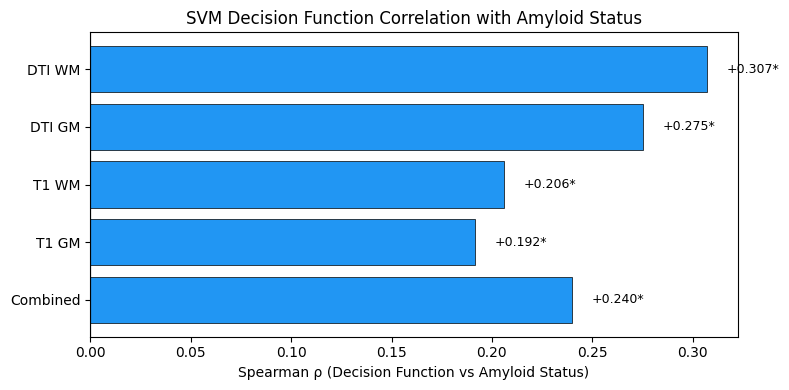

In [82]:
names = list(corr_results.keys())
rhos = [corr_results[n][0] for n in names]
pvals = [corr_results[n][1] for n in names]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#2196F3' if p < 0.05 else '#BDBDBD' for p in pvals]
bars = ax.barh(names, rhos, color=colors, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Spearman ρ (Decision Function vs Amyloid Status)')
ax.set_title('SVM Decision Function Correlation with Amyloid Status')
ax.axvline(0, color='black', linewidth=0.8)

for bar, rho, p in zip(bars, rhos, pvals):
    label = f'{rho:+.3f}{"*" if p < 0.05 else ""}'
    x_pos = rho + 0.01 if rho >= 0 else rho - 0.01
    ha = 'left' if rho >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2, label,
            va='center', ha=ha, fontsize=9)

ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [34]:
# Multi-class SVC: 4 classes from (label, label_amy) -> (0,0), (0,1), (1,0), (1,1)

# Filter features and labels to amyloid subset
amy_dti_files = set(paired_df_amy['dti_file_name'].values)
amy_mask = dti_masked_wm['file_name'].isin(amy_dti_files)

X_amy = X_combined_all[amy_mask]
# Build y_multi: (label, label_amy) -> 0,1,2,3
dti_to_amy = paired_df_amy.set_index('dti_file_name')
rows_amy = dti_masked_wm.loc[amy_mask]
y_label = np.array([dti_to_amy.loc[row['file_name'], 'label'] for _, row in rows_amy.iterrows()]).astype(int)
y_amy_num = pd.to_numeric([dti_to_amy.loc[row['file_name'], 'label_amy'] for _, row in rows_amy.iterrows()], errors='coerce').astype(int)
y_multi = y_label * 2 + y_amy_num

In [ ]:
# Class counts
for c in range(4):
    lb, am = [(0,0),(0,1),(1,0),(1,1)][c]
    n = (y_multi == c).sum()
    print(f"Class {c} (label={lb}, amy={am}): n={n}")
print()

# Train-test split and multi-class SVC
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_amy, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

svm_multi = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_multi.fit(X_train_m, y_train_m)
y_pred_m = svm_multi.predict(X_test_m)

acc_multi = balanced_accuracy_score(y_test_m, y_pred_m)
print(f"Multi-class balanced accuracy: {acc_multi:.4f}")
print("Classes: (0,0)=CN amy-, (0,1)=CN amy+, (1,0)=AD amy-, (1,1)=AD amy+")
print("Confusion matrix:")
print(confusion_matrix(y_test_m, y_pred_m, labels=[0, 1, 2, 3]))

Class 0 (label=0, amy=0): n=94
Class 1 (label=0, amy=1): n=18
Class 2 (label=1, amy=0): n=56
Class 3 (label=1, amy=1): n=32

Multi-class balanced accuracy: 0.6256
Classes: (0,0)=CN amy-, (0,1)=CN amy+, (1,0)=AD amy-, (1,1)=AD amy+
Confusion matrix:
[[13  3  0  3]
 [ 1  2  1  0]
 [ 2  0  9  0]
 [ 1  0  2  3]]


In [36]:
# T1-only pipeline
X_amy_t1 = np.hstack([t1_wm_pca, t1_gm_pca])[amy_mask]
X_t1_train_m, X_t1_test_m, _, _ = train_test_split(
    X_amy_t1, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)
svm_t1_multi = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_t1_multi.fit(X_t1_train_m, y_train_m)
y_pred_t1 = svm_t1_multi.predict(X_t1_test_m)
acc_t1 = balanced_accuracy_score(y_test_m, y_pred_t1)
print(f"T1-only - Multi-class balanced accuracy: {acc_t1:.4f}")
print("Confusion matrix:")
print(confusion_matrix(y_test_m, y_pred_t1, labels=[0, 1, 2, 3]))
print()

T1-only - Multi-class balanced accuracy: 0.6177
Confusion matrix:
[[16  2  1  0]
 [ 1  3  0  0]
 [ 2  3  6  0]
 [ 3  1  0  2]]



In [37]:
# DTI-only pipeline
X_amy_dti = np.hstack([dti_wm_pca, dti_gm_pca])[amy_mask]
X_dti_train_m, X_dti_test_m, _, _ = train_test_split(
    X_amy_dti, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)
svm_dti_multi = SVC(kernel='rbf', class_weight='balanced', random_state=42)
svm_dti_multi.fit(X_dti_train_m, y_train_m)
y_pred_dti = svm_dti_multi.predict(X_dti_test_m)
acc_dti = balanced_accuracy_score(y_test_m, y_pred_dti)
print(f"DTI-only - Multi-class balanced accuracy: {acc_dti:.4f}")
print("Confusion matrix:")
print(confusion_matrix(y_test_m, y_pred_dti, labels=[0, 1, 2, 3]))

DTI-only - Multi-class balanced accuracy: 0.6031
Confusion matrix:
[[11  5  3  0]
 [ 0  2  2  0]
 [ 0  0 11  0]
 [ 0  0  4  2]]
